In [1]:
from tqdm import tqdm
import jax.numpy as jnp
from flax import nnx
import matplotlib.pyplot as plt
import numpy as np 
import netket as nk
from netket.operator.spin import sigmax, sigmaz
from scipy.sparse.linalg import eigsh

/Users/sanzhar123/Desktop/Approximate-Symmetries-TC-main/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Using Netket and 2D Toric Code Hamiltonian to map out phase diagram. 

The plan is as follows. For a given L, write down Hamiltonian, 
and using Krylov Diagonalization find an approximate ground state (gs)
energy and gs wavefunction. Measure the A_v, sigma_z operators. 
We fix the value of h_x = 0.3, and sweep h_z from 0.0 to 0.75, 
looking for non-analyticity.

Another avenue latet woulbe - pick a Approx. Symm. Ansatz, 
run the NQS algorithm to obtain a ground state, and 
measure the A_v, sigma_z operators. We fix the value of h_x = 0.3, 
and sweep h_z from 0.0 to 0.75, looking for non-analyticity.

In [2]:
from model.geometry import ToricCodeGeometry
from model.hamiltonian import create_hamiltonian

geometry = ToricCodeGeometry(3, 3, 'PBC')

# Create the Hilbert space
hi = nk.hilbert.Spin(s=1/2, N=geometry.N)
    
# Create the Hamiltonian
Ham = create_hamiltonian(
    hi=hi,
    vertex_all=geometry.vertex_all,
    plaq_all=geometry.plaq_all,
    bonds=geometry.bonds,
    hx=0.0,
    hy=0.0,
    hz=0.0,
)

/Users/sanzhar123/Desktop/Approximate-Symmetries-TC-main/.venv/lib/python3.13/site-packages/netket/graph/lattice.py:329: UserWarning: Some atom positions are not unique. Duplicates were dropped, and now atom positions are [0.5]
  warnings.warn(


In [3]:
# Krylov Diagonalization 
eig_vals, eig_vecs = eigsh(Ham.to_sparse(), k=2, which="SA", return_eigenvectors=True)

print("eigenvalues with scipy sparse:", eig_vals)
E_gs = eig_vals[0]
wave_gs = eig_vecs.transpose()[0]

eigenvalues with scipy sparse: [-18. -18.]


In [12]:
# Observables: star sum A = Σ_v A_v, plaquette sum B = Σ_p B_p, magnetization Σ_i σ^z_i.
stars = geometry.get_vertex_all_hetero()
plaqs = geometry.plaq_all
N_v, N_p, N = len(stars), len(plaqs), geometry.N

A_op = 0
for star in stars:
    term = 1
    for i in star:
        term *= sigmax(hi, i)
    A_op += term

B_op = 0
for plaq in plaqs:
    term = 1
    for i in plaq:
        term *= sigmaz(hi, i)
    B_op += term

Mz_op = sum(sigmaz(hi, i) for i in range(N))

A_sp, B_sp, Mz_sp = A_op.to_sparse(), B_op.to_sparse(), Mz_op.to_sparse()

In [13]:
# Zero-field sanity check: every stabilizer is +1 in the unperturbed GS.
def expect(O, psi):
    return (psi.conj() @ O @ psi).real

print(f"<A_v> = {expect(A_sp, wave_gs) / N_v:.6f}")
print(f"<B_p> = {expect(B_sp, wave_gs) / N_p:.6f}")
print(f"<σ_z> = {expect(Mz_sp, wave_gs) / N:.6f}")

<A_v> = 1.000000
<B_p> = 1.000000
<σ_z> = 0.000000


In [198]:
h_z_list = np.linspace(0, 0.75, 20)
records = {k: [] for k in ("h_z", "E0", "gap", "A", "B", "Mz")}

for h_z in tqdm(h_z_list):
    Ham = create_hamiltonian(
        hi=hi,
        vertex_all=geometry.vertex_all,
        plaq_all=geometry.plaq_all,
        bonds=geometry.bonds,
        hx=0.3, hy=0.0, hz=h_z,
    )
    eig_vals, eig_vecs = eigsh(Ham.to_sparse(), k=4, which="SA", return_eigenvectors=True)
    psi = eig_vecs[:, 0]

    records["h_z"].append(h_z)
    records["E0"].append(eig_vals[0])
    records["gap"].append(eig_vals[1] - eig_vals[0])
    records["A"].append(expect(A_sp, psi) / N_v)
    records["B"].append(expect(B_sp, psi) / N_p)
    records["Mz"].append(expect(Mz_sp, psi) / N)

records = {k: np.array(v) for k, v in records.items()}

100%|██████████| 20/20 [02:42<00:00,  8.13s/it]


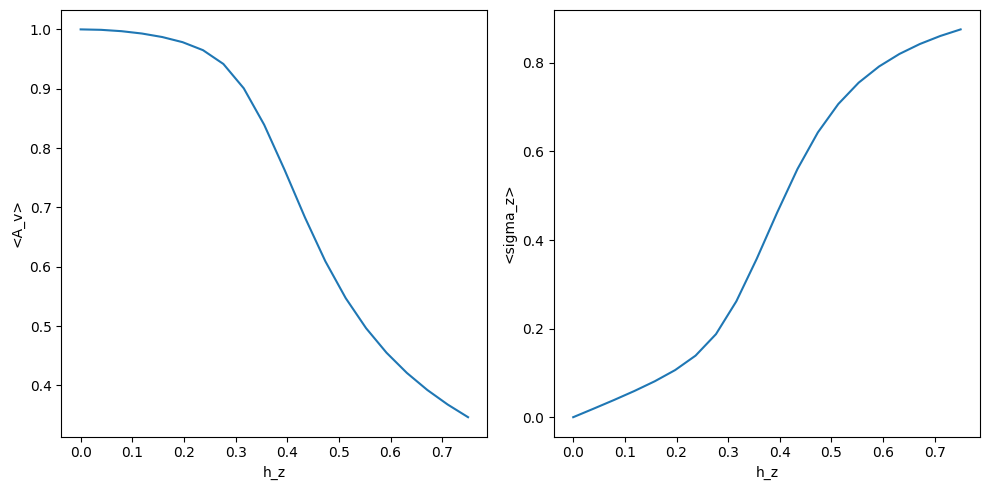

In [206]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].plot(records['h_z'], records['A'])
axs[0].set_xlabel('h_z')
axs[0].set_ylabel('<A_v>')

axs[1].plot(records['h_z'], records['Mz'])
axs[1].set_xlabel('h_z')
axs[1].set_ylabel('<sigma_z>')

# axs[2].plot(records['h_z'], records['gap'])
# axs[2].set_xlabel('h_z')
# axs[2].set_ylabel('E_0 - E_1')

plt.tight_layout() 

In [ ]:
# h_z-derivatives of the stabilizer / magnetization expectations.
# A continuous transition shows up as a susceptibility-like peak (or kink) in
# these slopes, the same diagnostic we use for the BFFM string below.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
panels = [
    ("A",  r"$\partial \langle A_v \rangle / \partial h_z$",      "C0"),
    ("B",  r"$\partial \langle B_p \rangle / \partial h_z$",      "C1"),
    ("Mz", r"$\partial \langle \sigma_z \rangle / \partial h_z$", "C2"),
]
for ax, (key, ylabel, color) in zip(axes, panels):
    deriv = np.gradient(records[key], records["h_z"])
    ax.plot(records["h_z"], deriv, "o-", markersize=4, color=color)
    ax.set_xlabel(r"$h_z$")
    ax.set_ylabel(ylabel)

fig.suptitle(r"$h_z$-derivatives of stabilizer expectations ($h_x = 0.3$)")
fig.tight_layout()
plt.show()

## Rotated surface code: same transition, half the qubits

The edge-qubit TC needs $2L^2$ qubits, so $L=4$ PBC is out of reach.  Rotating
the lattice puts qubits on **vertices**: $d^2$ qubits, plus a checkerboard of
weight-4 $X$- and $Z$-plaquettes and weight-2 boundary stabilizers.  Same
universality class as the TC, much smaller Hilbert space per code distance.
Concretely: $d=3 \to 9$ qubits, $d=4 \to 16$ qubits.

We reuse `create_hamiltonian` (which expects vertex-X / plaquette-Z lists) and
the same observables, so the only new ingredient is the geometry class.

In [4]:
from model.rotated_surface import RotatedSurfaceGeometry
from model.exact_diag import (
    hamiltonian_linop, expect_x_string, expect_z_string, qubits_to_mask,
)

def sweep_phase_diagram(geom, h_z_list, hx=0.3, k=4, label=""):
    """KD sweep over h_z at fixed h_x for a rotated surface code geometry.

    Matrix-free Lanczos (scipy LinearOperator backed by an on-the-fly matvec) —
    no sparse matrix is materialised, so this scales to d=5 (25 qubits, 33M dim)
    where Ham.to_sparse() becomes painful.

    Returns dict of arrays keyed by:
      h_z, E0, gap, A, B, Mz, Wx, Wz, Ox, Oz, bffm_x, bffm_z
    """
    N = geom.N
    basis = np.arange(1 << N, dtype=np.int64)

    cx, ox, cz, oz = geom.wilson_paths()
    masks = {
        "cx": qubits_to_mask(cx), "ox": qubits_to_mask(ox),
        "cz": qubits_to_mask(cz), "oz": qubits_to_mask(oz),
    }
    star_masks = [qubits_to_mask(s) for s in geom.get_vertex_all_hetero()]
    plaq_masks = [qubits_to_mask(p) for p in geom.plaq_all]
    site_masks = [1 << i for i in range(N)]

    keys = ("h_z", "E0", "gap", "A", "B", "Mz",
            "Wx", "Wz", "Ox", "Oz", "bffm_x", "bffm_z")
    rec = {k: [] for k in keys}

    for h_z in tqdm(h_z_list, desc=label):
        H, _ = hamiltonian_linop(geom, hx=hx, hy=0.0, hz=float(h_z), J=1.0)
        ev, vc = eigsh(H, k=k, which="SA", return_eigenvectors=True)
        psi = vc[:, 0]

        Wx = expect_x_string(psi, basis, masks["cx"])
        Ox = expect_x_string(psi, basis, masks["ox"])
        Wz = expect_z_string(psi, basis, masks["cz"], N)
        Oz = expect_z_string(psi, basis, masks["oz"], N)

        rec["h_z"].append(float(h_z))
        rec["E0"].append(float(ev[0]))
        rec["gap"].append(float(ev[1] - ev[0]))
        rec["A"].append(float(np.mean([expect_x_string(psi, basis, m) for m in star_masks])))
        rec["B"].append(float(np.mean([expect_z_string(psi, basis, m, N) for m in plaq_masks])))
        rec["Mz"].append(float(np.mean([expect_z_string(psi, basis, m, N) for m in site_masks])))
        rec["Wx"].append(Wx); rec["Ox"].append(Ox)
        rec["Wz"].append(Wz); rec["Oz"].append(Oz)
        rec["bffm_x"].append(Ox / np.sqrt(abs(Wx)) if abs(Wx) > 1e-14 else np.nan)
        rec["bffm_z"].append(Oz / np.sqrt(abs(Wz)) if abs(Wz) > 1e-14 else np.nan)

    return {k: np.array(v) for k, v in rec.items()}


In [5]:
h_z_list = np.linspace(0, 0.75, 50)
runs = {
    "d=3 surface": sweep_phase_diagram(RotatedSurfaceGeometry(3), h_z_list, label="d=3"),
    "d=4 surface": sweep_phase_diagram(RotatedSurfaceGeometry(4), h_z_list, label="d=4"),
    # "d=5 surface": sweep_phase_diagram(RotatedSurfaceGeometry(5), h_z_list, label="d=5"),
    # d=5 is 25 qubits / 33M states; needs >8 GB RAM to run as-is.
}


d=4: 100%|██████████| 50/50 [00:13<00:00,  3.62it/s]


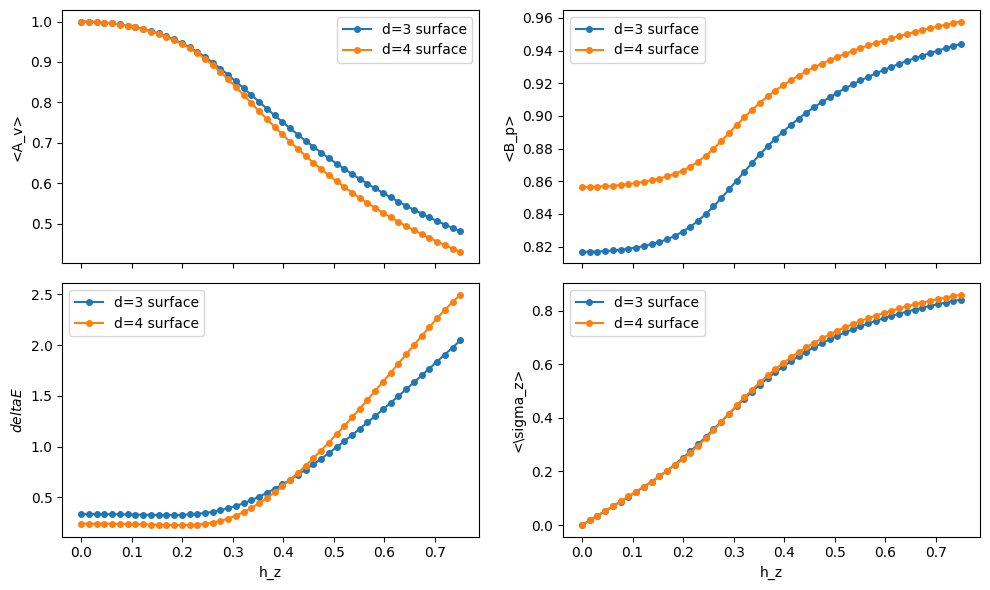

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
panels = [
    ("A",   r"<A_v>"),
    ("B",   r"<B_p>"),
    ("gap", r"$delta E$"),
    ("Mz",  r"<\sigma_z>"),
]

for ax, (key, ylabel) in zip(axes.flat, panels):
    for label, rec in runs.items():
        ax.plot(rec["h_z"], rec[key], "o-", markersize=4, label=label)
    ax.set_ylabel(ylabel)
    ax.legend()

for ax in axes[-1]:
    ax.set_xlabel(r"h_z")

fig.tight_layout()
plt.show()

### BFFM string order parameter and its $h_z$ derivative

Both $O_{BFFM}^{X/Z}$ are computed in the matrix-free sweep above from the half-string and full-string Wilson paths returned by `RotatedSurfaceGeometry.wilson_paths()` (defaults: horizontal row of $\sigma^x$ across the lattice for X, vertical column of $\sigma^z$ for Z; open halves use the first $\lceil d/2 \rceil$ sites).  The transition signature lives in $\partial O_{BFFM}^Z / \partial h_z$ (sweep is along $h_z$), and the peak should sharpen / shift with $d$ — that's the headline diagnostic.

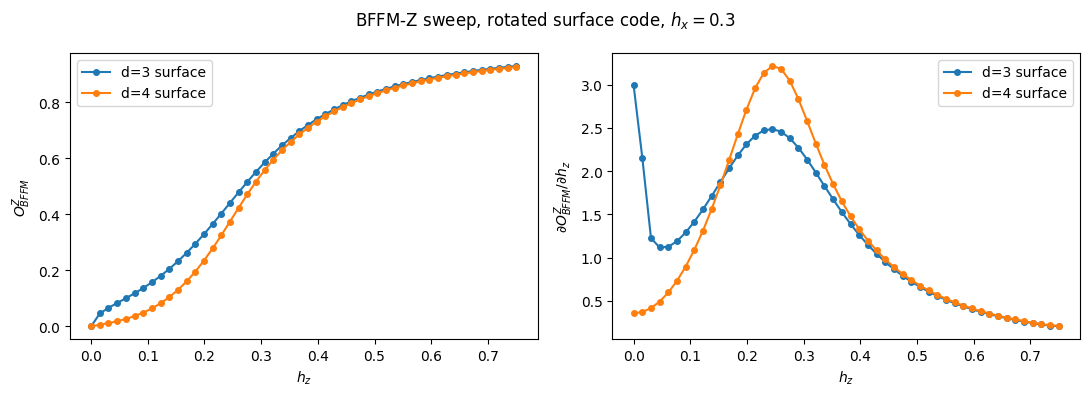

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for label, rec in runs.items():
    axes[0].plot(rec["h_z"], rec["bffm_z"], "o-", markersize=4, label=label)
    deriv = np.gradient(rec["bffm_z"], rec["h_z"])
    axes[1].plot(rec["h_z"], deriv, "o-", markersize=4, label=label)

axes[0].set_ylabel(r"$O_{BFFM}^Z$")
axes[1].set_ylabel(r"$\partial O_{BFFM}^Z / \partial h_z$")
for ax in axes:
    ax.set_xlabel(r"$h_z$")
    ax.legend()

fig.suptitle(r"BFFM-Z sweep, rotated surface code, $h_x=0.3$")
fig.tight_layout()
plt.show()


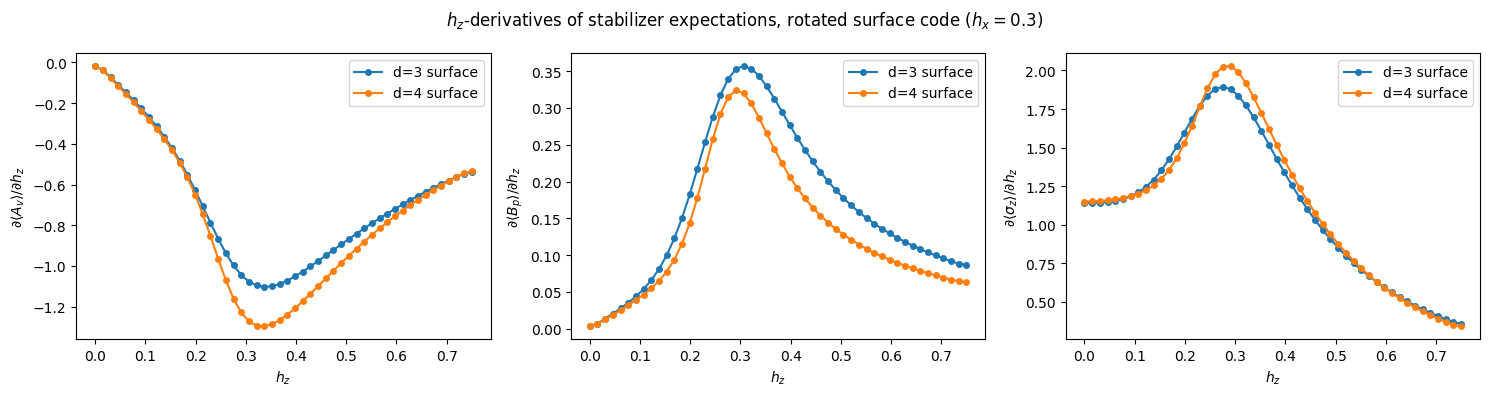

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
panels = [
    ("A",  r"$\partial \langle A_v \rangle / \partial h_z$"),
    ("B",  r"$\partial \langle B_p \rangle / \partial h_z$"),
    ("Mz", r"$\partial \langle \sigma_z \rangle / \partial h_z$"),
]
for ax, (key, ylabel) in zip(axes, panels):
    for label, rec in runs.items():
        ax.plot(rec["h_z"], np.gradient(rec[key], rec["h_z"]),
                "o-", markersize=4, label=label)
    ax.set_xlabel(r"$h_z$")
    ax.set_ylabel(ylabel)
    ax.legend()

fig.suptitle(r"$h_z$-derivatives of stabilizer expectations, rotated surface code ($h_x=0.3$)")
fig.tight_layout()
plt.show()

## 3D bosonic toric code, L=2 PBC, matrix-free KD sweep

Same matrix-free Lanczos approach, generalized to the 3D toric code Hamiltonian built by `Three_TC/model/geometry.py`.  At L=2 PBC we have $N = 3 \cdot 2^3 = 24$ qubits ($2^{24} \approx 16.8$ M states) — well within reach.  L=3 PBC would give $N = 81$, well past anything `eigsh` can handle.

The wonderful thing is that `model/exact_diag.py` is geometry-agnostic — it only consumes `geom.N`, `geom.vertex_all`, `geom.plaq_all`.  Both the 2D rotated surface and the 3D toric code geometries satisfy that interface, so we reuse the module verbatim.  Only the Wilson-string helper changes: in 3D PBC, the natural closed $\sigma^z$ loop is a line of qubits wrapping around the torus in one direction.

In [19]:
from Three_TC.model.geometry import ThreeD_ToricCodeGeometry

geom_3d = ThreeD_ToricCodeGeometry(2, 2, 2, 'PBC')
print(f'3D TC L=2 PBC:  N = {geom_3d.N},  |A_v| = {len(geom_3d.vertex_all)},  '
      f'|B_p| = {len(geom_3d.plaq_all)},  dim = 2^{geom_3d.N} = {1<<geom_3d.N:,}')

def z_line_qubits(geom, x: int = 0, y: int = 0):
    """Qubit indices of the sigma^z edges along the z-axis at column (x, y), PBC L=geom.Lz."""
    Lx2, Ly2, Lz2 = 2 * geom.Lx, 2 * geom.Ly, 2 * geom.Lz
    return [geom._coord_to_idx[((2 * x) % Lx2, (2 * y) % Ly2, (2 * z + 1) % Lz2)]
            for z in range(geom.Lz)]

closed_z3d = z_line_qubits(geom_3d, 0, 0)
open_z3d   = closed_z3d[: max(1, len(closed_z3d) // 2)]
print(f'closed Z-line: {closed_z3d}   open Z-string: {open_z3d}')

3D TC L=2 PBC:  N = 24,  |A_v| = 8,  |B_p| = 24,  dim = 2^24 = 16,777,216
closed Z-line: [8, 20]   open Z-string: [8]


In [20]:
# Zero-field sanity check: E0 = -(N_v + N_p), every stabilizer +1.
H, basis_3d = hamiltonian_linop(geom_3d, hx=0.0, hz=0.0, J=1.0)
ev, vc = eigsh(H, k=4, which='SA', tol=1e-7)
print(f'eigenvalues: {ev}')
psi = vc[:, 0]
A_vals = [expect_x_string(psi, basis_3d, qubits_to_mask(v)) for v in geom_3d.vertex_all]
B_vals = [expect_z_string(psi, basis_3d, qubits_to_mask(p), geom_3d.N) for p in geom_3d.plaq_all]
print(f'mean <A_v> = {np.mean(A_vals):.4f}    (expect 1.0)')
print(f'mean <B_p> = {np.mean(B_vals):.4f}    (expect 1.0)')
print(f'E0 = {ev[0]:.4f}                       (expect -{len(geom_3d.vertex_all) + len(geom_3d.plaq_all)})')

eigenvalues: [-32. -32. -28. -28.]
mean <A_v> = 1.0000    (expect 1.0)
mean <B_p> = 1.0000    (expect 1.0)
E0 = -32.0000                       (expect -32)


In [ ]:
def sweep_phase_diagram_3d(geom, h_z_list, hx=0.2, k=2, label="3D L=2 PBC"):
    """Matrix-free KD sweep over h_z for the 3D toric code."""
    N = geom.N
    basis = np.arange(1 << N, dtype=np.int64)

    cz = z_line_qubits(geom, 0, 0)
    oz = cz[: max(1, len(cz) // 2)]
    cz_mask, oz_mask = qubits_to_mask(cz), qubits_to_mask(oz)
    star_masks = [qubits_to_mask(v) for v in geom.vertex_all]
    plaq_masks = [qubits_to_mask(p) for p in geom.plaq_all]
    site_masks = [1 << i for i in range(N)]

    keys = ("h_z", "E0", "gap", "A", "B", "Mz", "Wz", "Oz", "bffm_z")
    rec = {k: [] for k in keys}

    for h_z in tqdm(h_z_list, desc=label):
        H, _ = hamiltonian_linop(geom, hx=hx, hy=0.0, hz=float(h_z), J=1.0)
        ev, vc = eigsh(H, k=k, which="SA", tol=1e-7, return_eigenvectors=True)
        psi = vc[:, 0]
        Wz = expect_z_string(psi, basis, cz_mask, N)
        Oz = expect_z_string(psi, basis, oz_mask, N)
        rec["h_z"].append(float(h_z))
        rec["E0"].append(float(ev[0]))
        rec["gap"].append(float(ev[1] - ev[0]))
        rec["A"].append(float(np.mean([expect_x_string(psi, basis, m) for m in star_masks])))
        rec["B"].append(float(np.mean([expect_z_string(psi, basis, m, N) for m in plaq_masks])))
        rec["Mz"].append(float(np.mean([expect_z_string(psi, basis, m, N) for m in site_masks])))
        rec["Wz"].append(Wz); rec["Oz"].append(Oz)
        rec["bffm_z"].append(Oz / np.sqrt(abs(Wz)) if abs(Wz) > 1e-14 else np.nan)

    return {k: np.array(v) for k, v in rec.items()}

rec_3d = sweep_phase_diagram_3d(geom_3d, h_z_list, hx=0.2, label="3D L=2 PBC")

3D L=2 PBC:   0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(rec_3d["h_z"], rec_3d["bffm_z"], "o-", color="C2", label="3D L=2 PBC")
axes[1].plot(rec_3d["h_z"], np.gradient(rec_3d["bffm_z"], rec_3d["h_z"]),
             "o-", color="C2", label="3D L=2 PBC")
axes[0].set_ylabel(r"$O_{BFFM}^Z$")
axes[1].set_ylabel(r"$\partial O_{BFFM}^Z / \partial h_z$")
for ax in axes:
    ax.set_xlabel(r"$h_z$")
    ax.legend()
fig.suptitle(r"3D bosonic TC, $h_x = 0.2$, $\sigma^z$ z-line")
fig.tight_layout()
plt.show()

# h_z-derivatives of the stabilizer / magnetization expectations.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
panels = [
    ("A",  r"$\partial \langle A_v \rangle / \partial h_z$"),
    ("B",  r"$\partial \langle B_p \rangle / \partial h_z$"),
    ("Mz", r"$\partial \langle \sigma_z \rangle / \partial h_z$"),
]
for ax, (key, ylabel) in zip(axes, panels):
    ax.plot(rec_3d["h_z"], np.gradient(rec_3d[key], rec_3d["h_z"]),
            "o-", color="C2", label="3D L=2 PBC")
    ax.set_xlabel(r"$h_z$")
    ax.set_ylabel(ylabel)
    ax.legend()
fig.suptitle(r"3D bosonic TC, $h_x = 0.2$: $h_z$-derivatives of stabilizer expectations")
fig.tight_layout()
plt.show()

The Hamiltonian change is one line: feed the decorated plaquette set
`fermionic_plaquettes(geom)` to `hamiltonian_linop` as `xz_stabs=`.  Each
plaquette becomes $\tilde B_p = (\prod_{e\in\partial p}\sigma^z_e)\,
\sigma^x_{e_+}\sigma^x_{e_-}$ (see `Three_TC/model/fermionic_decoration.py`).

**Order parameter.**  The bare $\sigma^z$ Wilson string is *not* conserved here
(it anticommutes with the decorated plaquettes), so we **dress it with
$\sigma^x$** via `dressed_string`, solving a small GF(2) system so the combined
operator commutes with every $\tilde B_p$:
- the **closed** wrapping loop dresses to a fully conserved Wilson loop $W$;
- the **open** half-string *cannot* be made flux-free — each endpoint carries a
  charge (violated star) **and** a flux (violated plaquette).  That charge+flux
  composite is the emergent **fermion**, and this string $S$ creates it.

We form the Fredenhagen–Marcu ratio $O_{FM}=\langle S\rangle/\sqrt{|\langle W\rangle|}$.

**L=2 caveat.**  At $L=2$ PBC the open string is a single edge with no bulk, so
$O_{FM}$ may be inconclusive; the conserved loop $\langle W\rangle$, the spectral
gap, and $\langle M_z\rangle$ are the reliable transition signals.  A clean
$O_{FM}$ needs $L\ge 3$–$4$, which is past exact-diagonalization reach.

In [21]:
from Three_TC.model.fermionic_decoration import (
    fermionic_plaquettes, verify_xz_commutation, dressed_string)
from model.exact_diag import expect_xz_string

geom_3df = ThreeD_ToricCodeGeometry(2, 2, 2, 'PBC')
stabs_f = fermionic_plaquettes(geom_3df, J=1.0)
chk = verify_xz_commutation(stabs_f, geom_3df.vertex_all)
print(f'fermionic 3D TC L=2 PBC:  N = {geom_3df.N},  |A_v| = {len(geom_3df.vertex_all)},  '
      f'|B~_p| = {len(stabs_f)},  commute = {chk["ok"]}  ({len(chk["violations"])} violations)')

# sigma^z strings dressed with sigma^x so they commute with the decorated plaquettes.
cz = z_line_qubits(geom_3df, 0, 0)            # wrapping loop
oz = cz[: max(1, len(cz) // 2)]               # open half (the fermion worldline)
W_z, W_x, W_flux = dressed_string(geom_3df, stabs_f, cz)   # conserved closed loop
S_z, S_x, S_flux = dressed_string(geom_3df, stabs_f, oz)   # open fermion string
print(f'closed loop : |s^z|={len(W_z)}, |s^x dressing|={len(W_x)}, '
      f'flux endpoints={len(W_flux)}  (0 => conserved)')
print(f'open string : |s^z|={len(S_z)}, |s^x dressing|={len(S_x)}, '
      f'flux endpoints={len(S_flux)}  (=> charge+flux fermion at each end)')

fermionic 3D TC L=2 PBC:  N = 24,  |A_v| = 8,  |B~_p| = 24,  commute = True  (0 violations)


In [22]:
# Zero-field sanity check: E0 = -(N_v + N_p), every decorated stabilizer +1.
H, basis_3df = hamiltonian_linop(geom_3df, hx=0.0, hz=0.0, J=1.0, xz_stabs=stabs_f)
ev, vc = eigsh(H, k=4, which='SA', tol=1e-7)
print(f'eigenvalues: {ev}')
psi = vc[:, 0]
A_vals = [expect_x_string(psi, basis_3df, qubits_to_mask(v)) for v in geom_3df.vertex_all]
B_vals = [expect_xz_string(psi, basis_3df, qubits_to_mask(z), qubits_to_mask(x), geom_3df.N)
          for z, x, _ in stabs_f]
print(f'mean <A_v>  = {np.mean(A_vals):.4f}    (expect 1.0)')
print(f'mean <B~_p> = {np.mean(B_vals):.4f}    (expect 1.0)')
print(f'E0 = {ev[0]:.4f}                       (expect -{len(geom_3df.vertex_all) + len(stabs_f)})')

eigenvalues: [-32. -32. -24. -24.]
mean <A_v>  = 1.0000    (expect 1.0)
mean <B~_p> = 1.0000    (expect 1.0)
E0 = -32.0000                       (expect -32)


In [ ]:
def sweep_phase_diagram_3d_fermionic(geom, stabs, h_z_list, hx=0.2, k=2,
                                     label="3D fermionic L=2 PBC"):
    """Matrix-free KD sweep over h_z for the 3D fermionic toric code.

    Order parameter: the sigma^x-dressed Wilson loop W (conserved) and the open
    dressed fermion string S, combined into the Fredenhagen-Marcu ratio
    O_FM = <S> / sqrt(|<W>|).  Gap and <M_z> are kept as robust diagnostics.
    """
    N = geom.N
    basis = np.arange(1 << N, dtype=np.int64)

    # Dressing is geometry-only -> build the string operators once.
    cz = z_line_qubits(geom, 0, 0)
    oz = cz[: max(1, len(cz) // 2)]
    W_z, W_x, _ = dressed_string(geom, stabs, cz)
    S_z, S_x, _ = dressed_string(geom, stabs, oz)
    Wz_mask, Wx_mask = qubits_to_mask(W_z), qubits_to_mask(W_x)
    Sz_mask, Sx_mask = qubits_to_mask(S_z), qubits_to_mask(S_x)
    star_masks = [qubits_to_mask(v) for v in geom.vertex_all]
    plaq_zx = [(qubits_to_mask(z), qubits_to_mask(x)) for z, x, _ in stabs]
    site_masks = [1 << i for i in range(N)]

    keys = ("h_z", "E0", "gap", "A", "B", "Mz", "W", "S", "O_FM")
    rec = {kk: [] for kk in keys}
    for h_z in tqdm(h_z_list, desc=label):
        H, _ = hamiltonian_linop(geom, hx=hx, hy=0.0, hz=float(h_z), J=1.0, xz_stabs=stabs)
        ev, vc = eigsh(H, k=k, which="SA", tol=1e-7, return_eigenvectors=True)
        psi = vc[:, 0]
        W = expect_xz_string(psi, basis, Wz_mask, Wx_mask, N)   # conserved Wilson loop
        S = expect_xz_string(psi, basis, Sz_mask, Sx_mask, N)   # fermion string
        rec["h_z"].append(float(h_z))
        rec["E0"].append(float(ev[0]))
        rec["gap"].append(float(ev[1] - ev[0]))
        rec["A"].append(float(np.mean([expect_x_string(psi, basis, m) for m in star_masks])))
        rec["B"].append(float(np.mean([expect_xz_string(psi, basis, zm, xm, N) for zm, xm in plaq_zx])))
        rec["Mz"].append(float(np.mean([expect_z_string(psi, basis, m, N) for m in site_masks])))
        rec["W"].append(W); rec["S"].append(S)
        rec["O_FM"].append(S / np.sqrt(abs(W)) if abs(W) > 1e-14 else np.nan)
    return {kk: np.array(v) for kk, v in rec.items()}

rec_3df = sweep_phase_diagram_3d_fermionic(geom_3df, stabs_f, h_z_list, hx=0.2,
                                           label="3D fermionic L=2 PBC")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(rec_3df["h_z"], rec_3df["O_FM"], "o-", color="C3", label="3D fermionic L=2 PBC")
axes[1].plot(rec_3df["h_z"], np.gradient(rec_3df["O_FM"], rec_3df["h_z"]),
             "o-", color="C3", label="3D fermionic L=2 PBC")
axes[0].set_ylabel(r"$O_{FM} = \langle S\rangle/\sqrt{|\langle W\rangle|}$")
axes[1].set_ylabel(r"$\partial O_{FM}/\partial h_z$")
for ax in axes:
    ax.set_xlabel(r"$h_z$"); ax.legend()
fig.suptitle(r"3D fermionic TC, $h_x = 0.2$: dressed Fredenhagen--Marcu ratio")
fig.tight_layout(); plt.show()

# Conserved Wilson loop, gap, magnetization: robust diagnostics.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(rec_3df["h_z"], rec_3df["W"], "o-", color="C3")
axes[1].plot(rec_3df["h_z"], rec_3df["gap"], "o-", color="C3")
axes[2].plot(rec_3df["h_z"], rec_3df["Mz"], "o-", color="C3")
axes[0].set_ylabel(r"$\langle W\rangle$ (conserved loop)")
axes[1].set_ylabel(r"spectral gap"); axes[2].set_ylabel(r"$\langle M_z\rangle$")
for ax in axes:
    ax.set_xlabel(r"$h_z$")
fig.suptitle(r"3D fermionic TC, $h_x = 0.2$: conserved loop, gap, magnetization")
fig.tight_layout(); plt.show()

# h_z-derivatives of the stabilizer / magnetization expectations.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
panels = [
    ("A",  r"$\partial \langle A_v \rangle / \partial h_z$"),
    ("B",  r"$\partial \langle \tilde B_p \rangle / \partial h_z$"),
    ("Mz", r"$\partial \langle \sigma_z \rangle / \partial h_z$"),
]
for ax, (key, ylabel) in zip(axes, panels):
    ax.plot(rec_3df["h_z"], np.gradient(rec_3df[key], rec_3df["h_z"]),
            "o-", color="C3", label="3D fermionic L=2 PBC")
    ax.set_xlabel(r"$h_z$")
    ax.set_ylabel(ylabel)
    ax.legend()
fig.suptitle(r"3D fermionic TC, $h_x = 0.2$: $h_z$-derivatives of stabilizer expectations")
fig.tight_layout(); plt.show()